In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

Setup

In [6]:
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from PIL import Image
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

print(DATA_DIR.exists())
print((DATA_DIR / "mountain").exists())

random.seed(42)


Using device: cuda
PyTorch version:     2.10.0+cu128
TorchVision version: 0.25.0+cu128
True
True


Tensor Question 1

In [7]:
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

b = torch.zeros(2, 3)
c = torch.ones(4)

for name, tensor in [("a", a), ("b", b), ("c", c)]:
    print(f"{name} =\n{tensor}")
    print(f"shape: {tensor.shape}")
    print(f"dtype: {tensor.dtype}")
    print(f"device: {tensor.device}")
    print()

# These tensors are currently on the CPU by default.
# In GPU training or inference, the model weights and input tensors must be on the same device,
# or PyTorch will raise a device mismatch error.



a =
tensor([[1., 2., 3.],
        [4., 5., 6.]])
shape: torch.Size([2, 3])
dtype: torch.float32
device: cpu

b =
tensor([[0., 0., 0.],
        [0., 0., 0.]])
shape: torch.Size([2, 3])
dtype: torch.float32
device: cpu

c =
tensor([1., 1., 1., 1.])
shape: torch.Size([4])
dtype: torch.float32
device: cpu



Tensor Question 2

In [8]:
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])

print(torch.sqrt(x))
print(x.sum())
print(x.mean())
print(x.argmax())
# In a classifier, argmax gives the index of the class with the highest score.
# For a 1,000-class model, that index is the predicted class ID.


tensor([1., 2., 3., 4., 5.])
tensor(55.)
tensor(11.)
tensor(4)


Tensor Question 3

In [9]:
a_gpu = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

a_back = a_gpu.cpu()
a_numpy = a_back.numpy()
print(f"numpy type: {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

# PyTorch requires .cpu() before .numpy() because NumPy arrays live in CPU memory.
# A tensor on the GPU must be moved back to the CPU before NumPy can use it.


a_gpu device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


Tensor Question 4

In [10]:
t = torch.arange(24).float()

t1 = t.reshape(4, 6)
print(t1.shape)

t2 = t.reshape(2, 3, 4)
print(t2.shape)

t3 = t1.unsqueeze(0)
print(t3.shape)

# Adding a batch dimension is done with unsqueeze(0).
# This matters because neural networks expect input in batch form:
# (batch_size, channels, height, width), even for one image.


torch.Size([4, 6])
torch.Size([2, 3, 4])
torch.Size([1, 4, 6])


Tensor Question 5

In [11]:
np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

t_a = torch.tensor(np_a, dtype=torch.float32)
t_b = torch.tensor(np_b, dtype=torch.float32)

np_result = np_a @ np_b
torch_result = t_a @ t_b

print("NumPy result:")
print(np_result)

print("PyTorch result:")
print(torch_result)

print("Outputs match:", np.allclose(np_result, torch_result.numpy()))

# Matrix multiplication combines inputs with learned weights.
# That is one of the core operations inside a neural network layer.


NumPy result:
[[19. 22.]
 [43. 50.]]
PyTorch result:
tensor([[19., 22.],
        [43., 50.]])
Outputs match: True


Model Question 1

In [12]:
weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Starting from pretrained weights saves a huge amount of time and compute.
# It lets you use a model that already learned useful visual features
# instead of training millions of parameters from scratch.


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


Total parameters:     11,689,512
Trainable parameters: 11,689,512


Model Question 2

In [13]:
print(model)
# The final layer is named fc and its output size is 1000,
# which matches the 1000 ImageNet classes.
# A deep network has many layers stacked together so it can learn
# increasingly complex features from low-level patterns to high-level objects.


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Model Question 3

In [14]:
model = model.to(device)
model.eval()
print("Model ready for inference.")

# .to(device) moves the model to the same device as the input tensors.
# This is necessary because model and data must be on the same device.
# model.eval() switches the model to evaluation mode.
# Layers like dropout and batch normalization behave differently
# during training and evaluation.


Model ready for inference.


Model Question 4

In [15]:
preprocess = weights.transforms()
print(preprocess)

# Resize and crop make the image the correct size for the model.
# ToTensor converts pixel values into a tensor, typically scaling them to [0, 1].
# Normalization adjusts the values using ImageNet's mean and standard deviation
# so the input matches what the pretrained model saw during training.


ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [16]:
#Image Helper
imagenet_classes = weights.meta["categories"]
print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")

def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR / label
    image_paths = [
        p for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ]
    print(f"{label}: found {len(image_paths)} images in {class_dir}")
    if not image_paths:
        raise ValueError(f"No image files found in {class_dir}")
    img_path = random.choice(image_paths)
    return Image.open(img_path).convert("RGB"), img_path.name


Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


Inference Question 1

In [17]:
def get_top5_predictions(model, preprocess, image, device, class_labels):
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)

    probs = torch.nn.functional.softmax(output[0], dim=0)
    top_probs, top_indices = torch.topk(probs, 5)

    results = []
    for prob, idx in zip(top_probs, top_indices):
        results.append((class_labels[idx.item()], prob.item()))

    return results


In [18]:
img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"  {class_name:30s}  {prob:.4f}")
    
# The top prediction does not need to literally be "mountain" to make sense.
# Labels like "alp", "valley", or "lakeside" can still be reasonable matches.


mountain: found 525 images in /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/mountain

Top-5 predictions for '24204.jpg':
  alp                             0.4911
  volcano                         0.2076
  valley                          0.2016
  promontory                      0.0184
  mountain tent                   0.0169


Inference Question 2

In [19]:
for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]
    print(f"\n[{label}]  {img_name}")
    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")
# The model is usually more confident on visually distinctive scenes
# and less confident on scenes that overlap with many ImageNet categories.


buildings: found 437 images in /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/buildings

[buildings]  24258.jpg
  palace                          0.4301
  gondola                         0.1305
  monastery                       0.0624
forest: found 474 images in /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/forest

[forest]  23309.jpg
  viaduct                         0.3853
  totem pole                      0.1089
  cliff                           0.0419
glacier: found 553 images in /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/glacier

[glacier]  20272.jpg
  volcano                         0.3854
  valley                          0.3297
  promontory                      0.1216
mountain: found 525 images in /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/mountain

[mountain]  20662.jpg
  ski                             0.5933
  alp                           

Inference Question 3

In [20]:
img, _ = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit  range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob   range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")

# Models output logits because they are convenient and numerically stable during training.
# Probabilities are easier to interpret for low-confidence filtering in production.



forest: found 474 images in /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/forest
Logit  range: min=-4.87, max=6.61
Prob   range: min=0.000001, max=0.0979
Probs sum to: 1.000000
Top prediction: mountain bike  (0.0979)


 Inference Question 4

sea: found 510 images in /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/sea


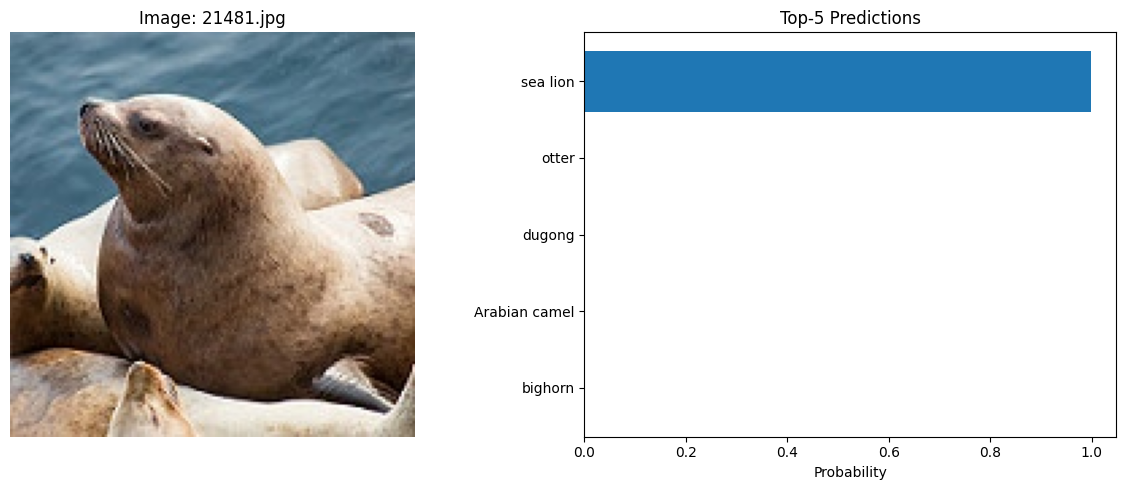

In [21]:
img, img_name = load_sample_image("sea")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

labels = [p[0] for p in preds]
probs = [p[1] for p in preds]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img)
axes[0].set_title(f"Image: {img_name}")
axes[0].axis("off")

axes[1].barh(labels[::-1], probs[::-1])
axes[1].set_title("Top-5 Predictions")
axes[1].set_xlabel("Probability")

plt.tight_layout()
plt.savefig("outputs/warmup_inference_viz.png")
plt.show()
# For a dashboard, this could highlight low-confidence predictions for human review.
# A top-1 probability threshold such as 0.70 or 0.80 could be a reasonable review trigger.

# Some predictions are semantically imperfect because the model was trained on ImageNet object classes,
# not the six scene labels in this dataset. A sea scene being predicted as "sea lion" shows that the
# model can latch onto related visual patterns without matching the intended scene category exactly.


sea: found 510 images in /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/sea


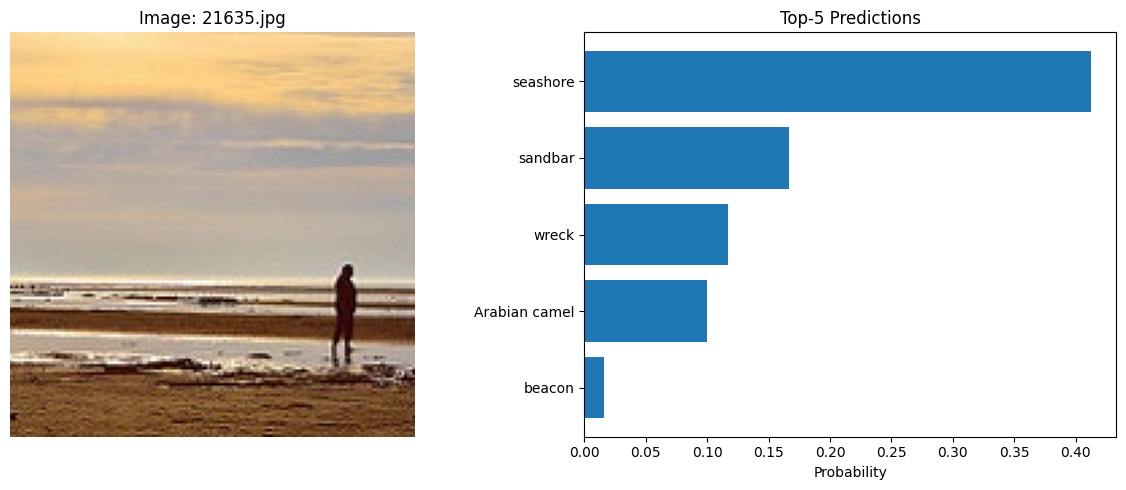

In [23]:
img, img_name = load_sample_image("sea")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

labels = [p[0] for p in preds]
probs = [p[1] for p in preds]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img)
axes[0].set_title(f"Image: {img_name}")
axes[0].axis("off")

axes[1].barh(labels[::-1], probs[::-1])
axes[1].set_title("Top-5 Predictions")
axes[1].set_xlabel("Probability")

plt.tight_layout()
plt.savefig("outputs/warmup_inference_viz.png")
plt.show()


In [24]:
from pathlib import Path
print(Path("outputs/warmup_inference_viz.png").exists())


True
